In [ ]:
# ライブラリのインストール（環境にない場合のみ実行）
!pip install japanize-matplotlib


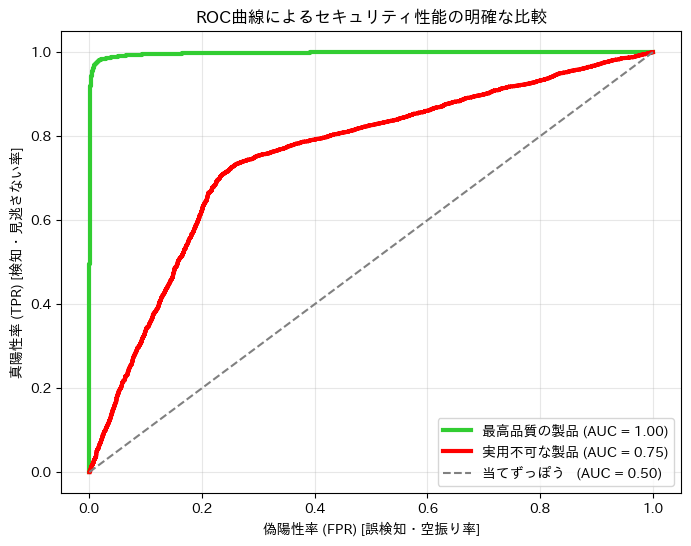

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# 1. データの作成
# 最高品質：識別しやすい
X_ex,   y_ex = make_classification(
    n_samples            = 10000,
    n_features           =    2,
    n_redundant          =    0,
    n_informative        =    2,
    n_clusters_per_class =    1,
    flip_y               =    0.001,    #1/1000(0.1%)が誤ったデータ
    random_state         =   42
)

# 実用不可：ノイズだらけ
X_poor, y_poor = make_classification(
    n_samples            = 10000,
    n_features           =    2,
    n_redundant          =    0,
    n_informative        =    1,
    n_clusters_per_class =    1,
    flip_y               =    0.5,      #1/2(50％)が誤ったデータ
    random_state         =   42)

# 2. モデル学習と確率予測
model = LogisticRegression()
y_score_ex   = model.fit(X_ex,   y_ex  ).predict_proba(X_ex  )[:, 1]
y_score_poor = model.fit(X_poor, y_poor).predict_proba(X_poor)[:, 1]

# 3. ROC/AUC計算
fpr_ex,   tpr_ex,   _ = roc_curve(y_ex,   y_score_ex)
fpr_poor, tpr_poor, _ = roc_curve(y_poor, y_score_poor)

# 4. 描画
plt.figure(figsize=(8, 6))
plt.plot(fpr_ex,   tpr_ex,   color='limegreen', lw=3,           label=f'最高品質の製品 (AUC = {auc(fpr_ex,   tpr_ex)  :.2f})')
plt.plot(fpr_poor, tpr_poor, color='red',       lw=3,           label=f'実用不可な製品 (AUC = {auc(fpr_poor, tpr_poor):.2f})')
plt.plot([0, 1], [0, 1],     color='gray',      linestyle='--', label= '当てずっぽう   (AUC = 0.50)')

plt.xlabel('偽陽性率 (FPR) [誤検知・空振り率]')
plt.ylabel('真陽性率 (TPR) [検知・見逃さない率]')
plt.title('ROC曲線によるセキュリティ性能の明確な比較')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

GIGO (Garbage In, Garbage Out：ゴミを入れたらゴミしか出てこない）

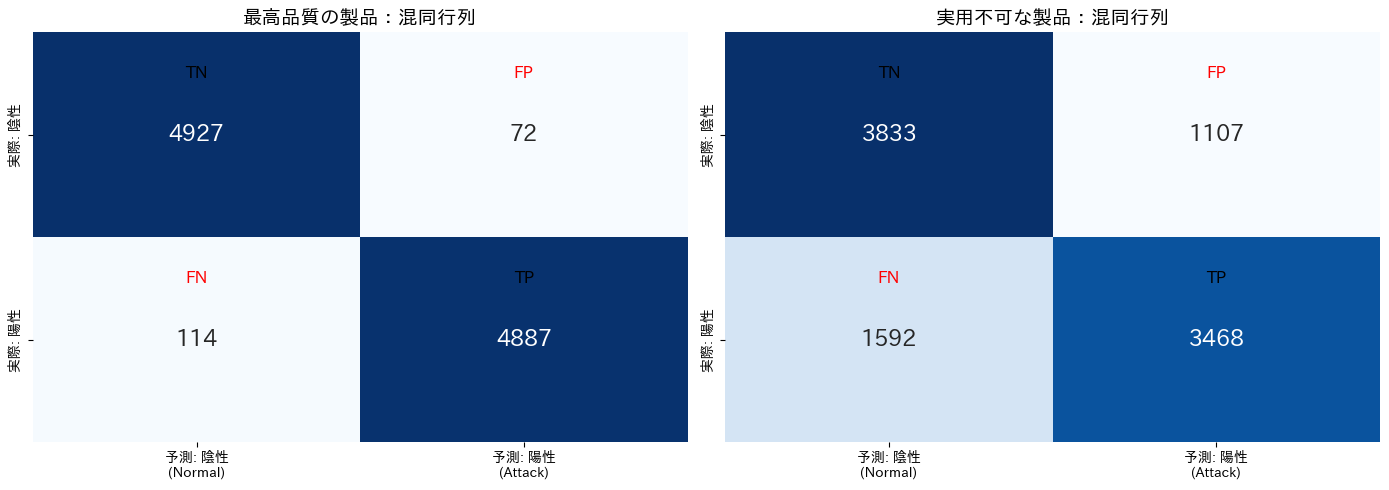

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. 予測ラベルの取得（デフォルトのしきい値 0.5 を使用）
y_pred_ex   = model.fit(X_ex,   y_ex  ).predict(X_ex)
y_pred_poor = model.fit(X_poor, y_poor).predict(X_poor)

# 2. 混同行列の計算
cm_ex   = confusion_matrix(y_ex,   y_pred_ex)
cm_poor = confusion_matrix(y_poor, y_pred_poor)

# 3. 描画
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_cm(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 16},
                xticklabels=['予測: 陰性\n(Normal)', '予測: 陽性\n(Attack)'],
                yticklabels=['実際: 陰性', '実際: 陽性'])
    ax.set_title(title, fontsize=14)
    # 各セルのラベル付け (TP, FN, FP, TN)
    ax.text(0.5, 0.2, 'TN', ha='center', va='center', color='black', fontsize=12)
    ax.text(1.5, 0.2, 'FP', ha='center', va='center', color='red',   fontsize=12)
    ax.text(0.5, 1.2, 'FN', ha='center', va='center', color='red',   fontsize=12)
    ax.text(1.5, 1.2, 'TP', ha='center', va='center', color='black', fontsize=12)

plot_cm(cm_ex,   '最高品質の製品：混同行列', axes[0])
plot_cm(cm_poor, '実用不可な製品：混同行列', axes[1])

plt.tight_layout()
plt.show()

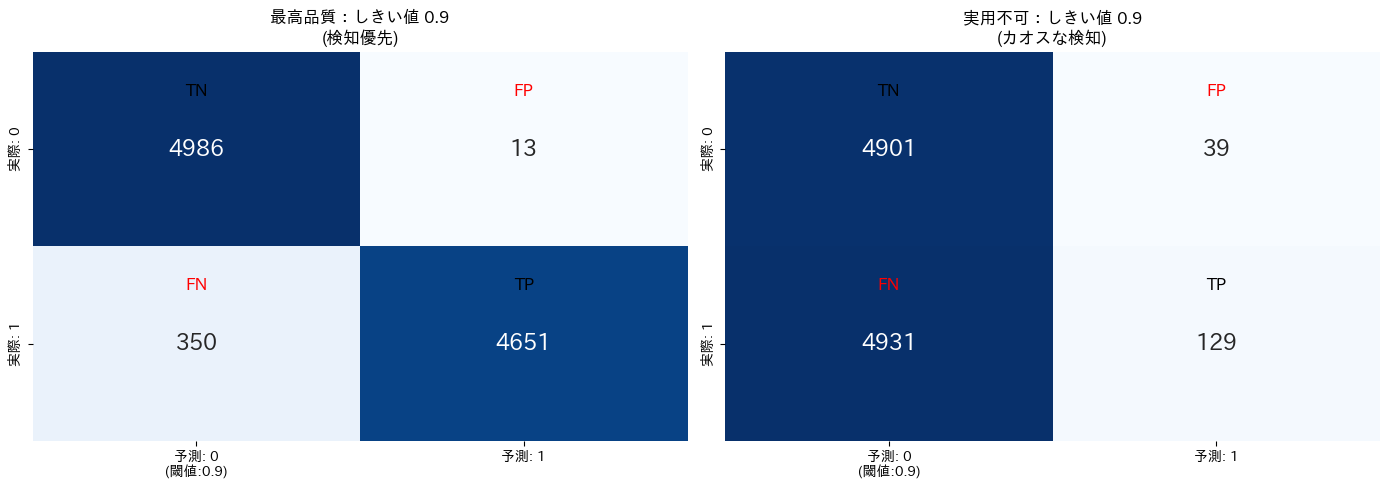

In [ ]:
def plot_custom_threshold_cm(y_true, y_probs, threshold, title, ax):
    """
    指定したしきい値で予測ラベルを決定し、混同行列を描画する
    """
    # しきい値に基づいて 0 or 1 を判定
    y_pred_custom = (y_probs >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred_custom)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 16},
                xticklabels=[f'予測: 0\n(閾値:{threshold})', '予測: 1'],
                yticklabels=['実際: 0', '実際: 1'])

    ax.set_title(title, fontsize=12)
    # 補助ラベル (TN, FP, FN, TP)
    ax.text(0.5, 0.2, 'TN', ha='center', va='center', color='black', fontsize=12)
    ax.text(1.5, 0.2, 'FP', ha='center', va='center', color='red',   fontsize=12)
    ax.text(0.5, 1.2, 'FN', ha='center', va='center', color='red',   fontsize=12)
    ax.text(1.5, 1.2, 'TP', ha='center', va='center', color='black', fontsize=12)

# --- 実行例 ---
target_threshold = 0.9         # 低い値を設定するとFP(誤検知)が増える、大きな値を設定するとFN(見逃し)が増える

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_custom_threshold_cm(y_ex, y_score_ex, target_threshold,
                         f'最高品質：しきい値 {target_threshold}\n(検知優先)', axes[0])

plot_custom_threshold_cm(y_poor, y_score_poor, target_threshold,
                         f'実用不可：しきい値 {target_threshold}\n(カオスな検知)', axes[1])

plt.tight_layout()
plt.show()

■ 高性能なスパムフィルタ：誤検知をほぼ出さずに、スパムを撃退できる


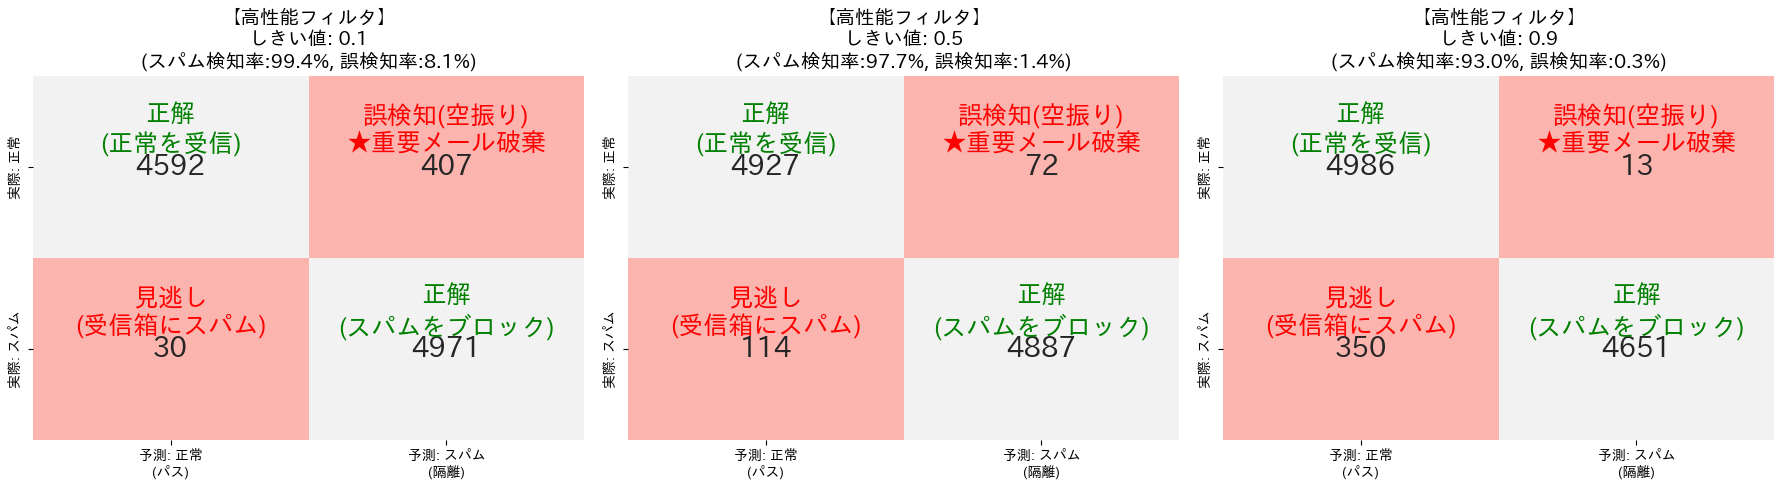


■ 粗悪なスパムフィルタ：スパムを消そうとすると、大事なメールまで誤検知で消えてしまう


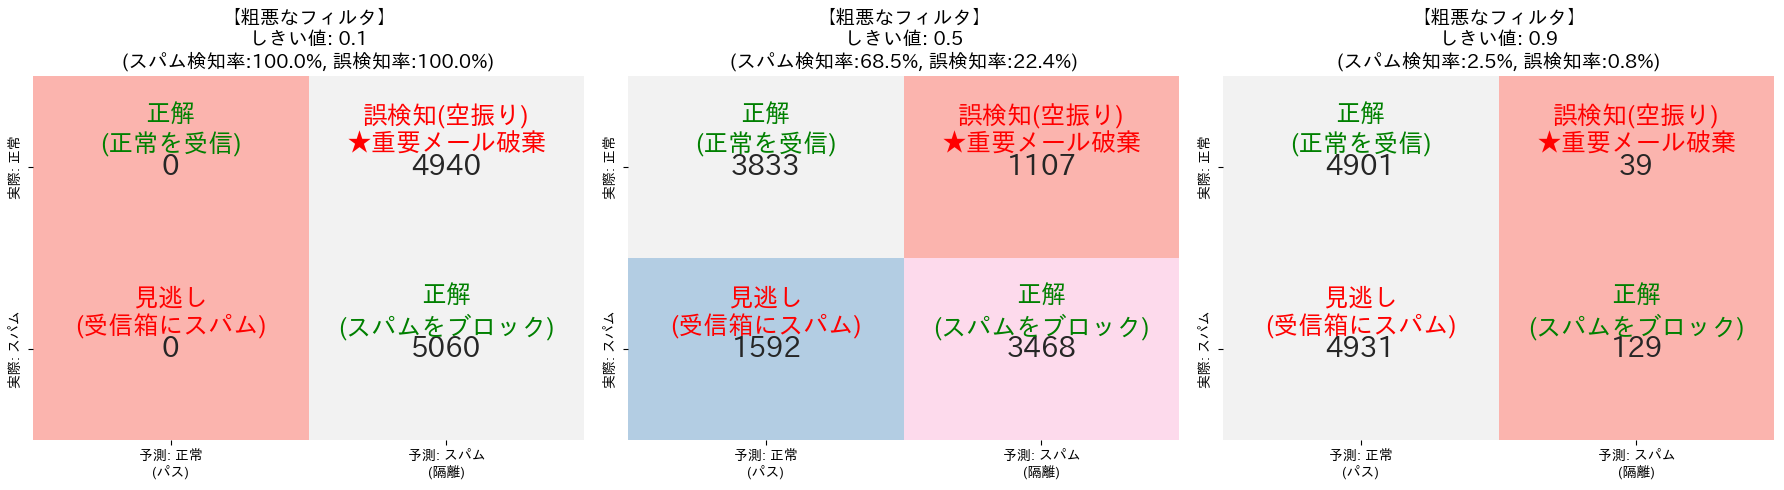

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_spam_filter_comparison(y_true, y_probs, thresholds, title_prefix):
    fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 5))

    # 凡例用の色の設定（誤検知=赤、見逃し=オレンジ、正解=緑系統）
    for i, thresh in enumerate(thresholds):
        # しきい値でスパム(1)か正常(0)かを判定
        y_pred = (y_probs >= thresh).astype(int)
        cm = confusion_matrix(y_true, y_pred)

        # ヒートマップ描画
        sns.heatmap(cm, annot=True, fmt='d', cmap='Pastel1', ax=axes[i], cbar=False,
                    annot_kws={"size": 20, "weight": "bold"},
                    xticklabels=['予測: 正常\n(パス)', '予測: スパム\n(隔離)'],
                    yticklabels=['実際: 正常', '実際: スパム'])

        tn, fp, fn, tp = cm.ravel()
        # 指標計算
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0    # スパム検知率
        fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0    # 誤検知率（空振り）

        axes[i].set_title(f'【{title_prefix}】\nしきい値: {thresh:.1f}\n(スパム検知率:{recall:.1%}, 誤検知率:{fpr:.1%})', fontsize=14)

        # 各セルのラベル付け
        axes[i].text(0.5, 0.3, '正解\n(正常を受信)',                ha='center', va='center', color='green', fontsize=18)
        axes[i].text(1.5, 0.3, '誤検知(空振り)\n★重要メール破棄',  ha='center', va='center', color='red',   fontsize=18, fontweight='bold')
        axes[i].text(0.5, 1.3, '見逃し\n(受信箱にスパム)',          ha='center', va='center', color='red',   fontsize=18)
        axes[i].text(1.5, 1.3, '正解\n(スパムをブロック)',          ha='center', va='center', color='green', fontsize=18)

    plt.tight_layout()
    plt.show()

# しきい値設定
# 0.1: 少しでも怪しければブロック（攻撃的）
# 0.9: 確実にスパムなものだけブロック（保守的）
spam_thresholds = [0.1, 0.5, 0.9]

print("■ 高性能なスパムフィルタ：誤検知をほぼ出さずに、スパムを撃退できる")
plot_spam_filter_comparison(y_ex, y_score_ex, spam_thresholds, "高性能フィルタ")

print("\n■ 粗悪なスパムフィルタ：スパムを消そうとすると、大事なメールまで誤検知で消えてしまう")
plot_spam_filter_comparison(y_poor, y_score_poor, spam_thresholds, "粗悪なフィルタ")